# PyTorch : Paper Replicating

(Date - 25/June/2026)

## 0. Getting setup (imports)

In [72]:
import torch
import torchvision
import sys
from pathlib import Path
import importlib
sys.path.append(str(Path.cwd().parent))
from helper_functions import set_seeds, download_data, plot_loss_curves
from going_modular import data_setup, engine, utils, predict
importlib.reload(predict)
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torchinfo import summary
import random
from summary_writer import create_writer
from helper_functions import plot_loss_curves, download_data
import requests

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

## 1. Getting data ready

In [7]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [8]:
train_dir = str(image_path / "train")
test_dir = str(image_path / "test")

## 2. Creating datasets and dataloaders

### 2.1 Creating a tranform manually

In [9]:
IMG_SIZE = 224

manual_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

print(f"Manually created transform: {manual_transform}")

Manually created transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Setting up dataloaders

In [10]:
BATCH_SIZE = 32

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transform=manual_transform,
    test_transform=manual_transform,
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1ae24543e90>,
 ['pizza', 'steak', 'sushi'])

### 2.3 Visualizing a single image

In [11]:
image_batch, label_batch = next(iter(train_dataloader))
image, label = image_batch[0], label_batch[0]
image.shape, label

(torch.Size([3, 224, 224]), tensor(2))

Text(0.5, 1.0, 'Label: sushi\nImage shape: torch.Size([3, 224, 224])')

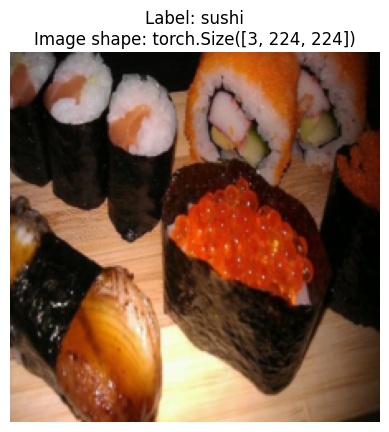

In [12]:
plt.imshow(image.permute(1,2,0))
plt.axis("off")
plt.title(f"Label: {class_names[label]}\nImage shape: {image.shape}")

## 3. Replicating the ViT (Vision Transformer) paper: an Overview

You may get an amazing overview from [here.](https://www.learnpytorch.io/08_pytorch_paper_replicating/#3-replicating-the-vit-paper-an-overview)


## 4. Equation 1: Split data into patches and creating the class, position and patch embedding

(Date - 3/July/2026)


### 4.1 Calculating patch embedding input and output shapes by hand

In [13]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height*width)/patch_size**2)
print(f"Number of patches (N) with:\nheight = {height} | width = {width} | patch_size = {patch_size}\nis {number_of_patches}")

Number of patches (N) with:
height = 224 | width = 224 | patch_size = 16
is 196


In [14]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = {number_of_patches, patch_size**2 * color_channels}

print(f"embedding_layer_input_shape (single 2D image) : {embedding_layer_input_shape}")
print(f"embedding_layer_output_shape (single 2D image flatten into patches) : {embedding_layer_output_shape}")

embedding_layer_input_shape (single 2D image) : (224, 224, 3)
embedding_layer_output_shape (single 2D image flatten into patches) : {768, 196}


### 4.2 Turning a single image into patches

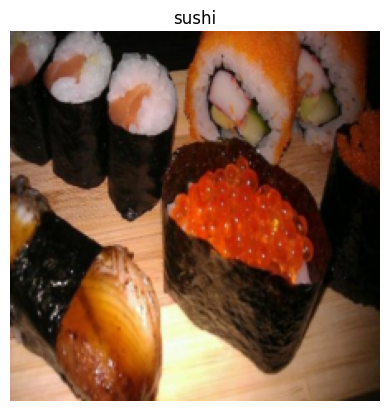

In [15]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off");

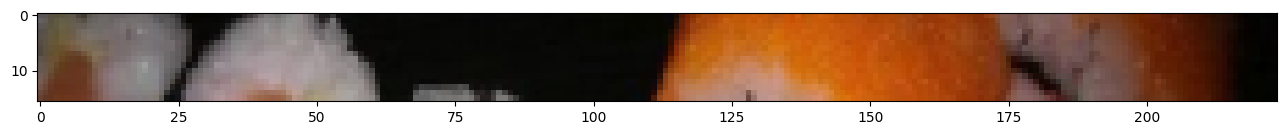

In [16]:
permuted_image = image.permute(1,2,0)

plt.figure(figsize=(patch_size, patch_size))
plt.imshow(permuted_image[:patch_size, :, :]);

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


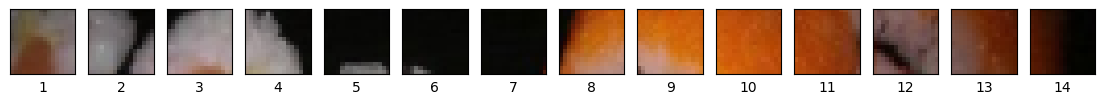

In [17]:
img_size = 224
patch_size = 16
num_patches = img_size/patch_size

assert img_size % patch_size == 0, "Image size must be divisible by the patch size."
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(nrows=1,
                       ncols=img_size//patch_size,
                       figsize=(num_patches, num_patches),
                       sharex=True,
                       sharey=True)

for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(permuted_image[:patch_size, patch:patch+patch_size, :]); # This prints the first row
    # axs[i].imshow(permuted_image[patch:patch+patch_size, :patch_size, :]) # This prints the first column
    axs[i].set_xlabel(i+1) 
    axs[i].set_xticks([])
    axs[i].set_yticks([])

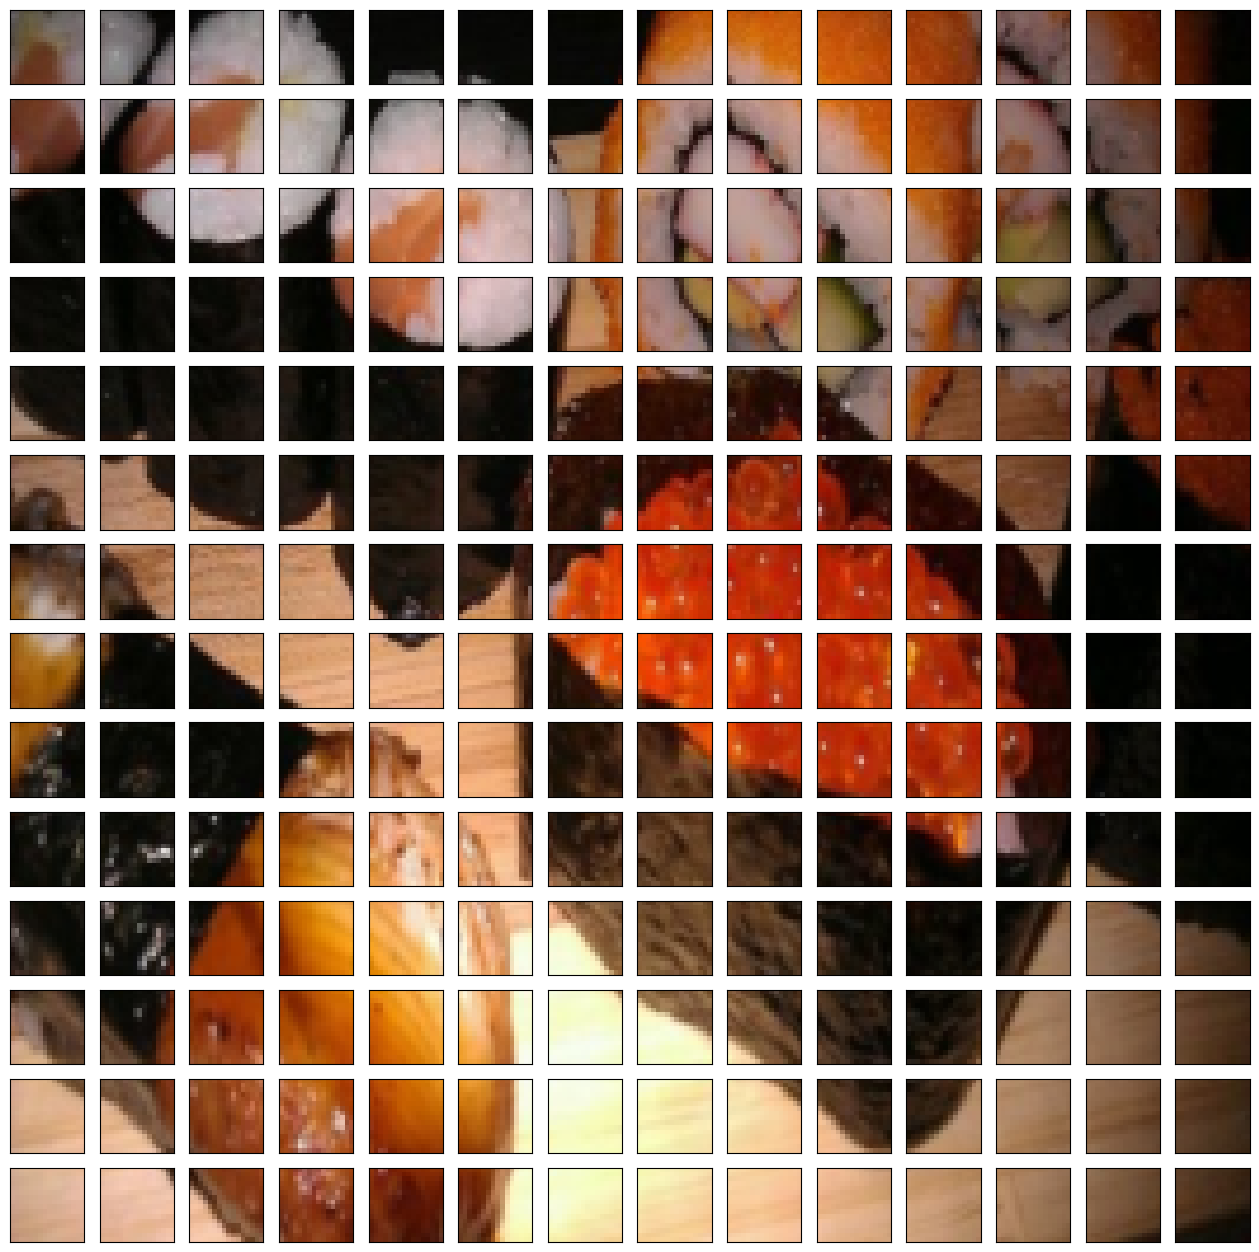

In [18]:
fig, axis = plt.subplots(nrows=img_size//patch_size,
                         ncols=img_size//patch_size,
                         figsize=(patch_size, patch_size),
                         sharex=True,
                         sharey=True)

k = 0
for j in range(14):
    for i, patch in enumerate(range(0, img_size, patch_size)):
        axis[j, i].imshow(permuted_image[k:k+patch_size, patch:patch+patch_size, :]); # This prints the first row
        # axs[i].imshow(permuted_image[patch:patch+patch_size, :patch_size, :]) # This prints the first column
        # axs[j, i].set_xlabel(i+1) 
        axis[j, i].set_xticks([])
        axis[j, i].set_yticks([])
    k+=16


### 4.3 Creating image patches with torch.nn.Conv2d()

In [19]:
# Set the patch size
patch_size=16

# Create the Conv2d layer with hyperparameters from the ViT paper
conv2d = nn.Conv2d(in_channels=3, # number of color channels
                   out_channels=768, # from Table 1: Hidden size D, this is the embedding size
                   kernel_size=patch_size, # could also use (patch_size, patch_size)
                   stride=patch_size,
                   padding=0)

In [20]:
# Pass the image through the convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(0)) # add a single batch dimension (height, width, color_channels) -> (batch, height, width, color_channels)
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


Showing random indices: [665, 736, 488, 167, 258]


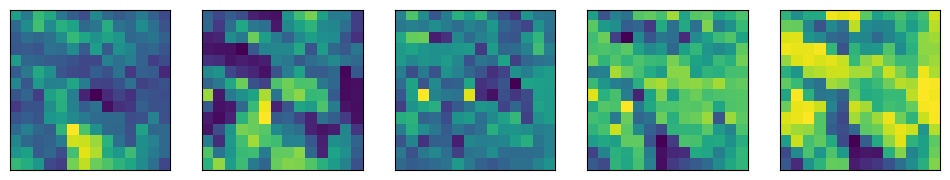

In [21]:
random_indices = random.sample(range(0, 768), k=5)
print(f"Showing random indices: {random_indices}")

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12,12))

for i, idx in enumerate(random_indices):
    img_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(img_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticks=[], yticks=[], xticklabels=[], yticklabels=[]);


In [22]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-0.4278, -0.4192, -0.5357, -0.2794, -0.0830, -0.0814, -0.0533,
           -0.6024, -0.8385, -0.6450, -0.5340, -0.3924, -0.4675, -0.1108],
          [-0.4240, -0.3813, -0.6846, -0.5875, -0.6385, -0.5150, -0.3104,
           -0.6459, -0.6922, -0.8397, -0.5359, -0.3792, -0.3603, -0.1385],
          [-0.0844, -0.2757, -0.4049, -0.4699, -0.7528, -0.7255, -0.7250,
           -0.6453, -0.6403, -0.5853, -0.6483, -0.4514, -0.2539, -0.1566],
          [-0.0615, -0.0747, -0.0964, -0.1452, -0.4287, -0.6750, -0.4248,
           -0.4821, -0.5968, -0.5171, -0.5079, -0.3700, -0.2762, -0.2775],
          [-0.2499, -0.1287, -0.1178, -0.1076, -0.0845, -0.0960, -0.4230,
           -0.3543, -0.2892, -0.2657, -0.4694, -0.3965, -0.2744, -0.3111],
          [-0.4714, -0.5032, -0.2465, -0.1626, -0.1219, -0.1495, -0.1992,
           -0.3728, -0.4869, -0.2994, -0.2576, -0.3391, -0.1128, -0.2640],
          [-0.4340, -0.4702, -0.6860, -0.6798, -0.2160, -0.2850, -0.6415,
           -0.6901, -0.6702, -0.

### 4.4 Flattening the patches using `torch.nn.Flatten()`

(Date - 4/July/2026)

In [23]:
# Current tensor shape
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


In [24]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


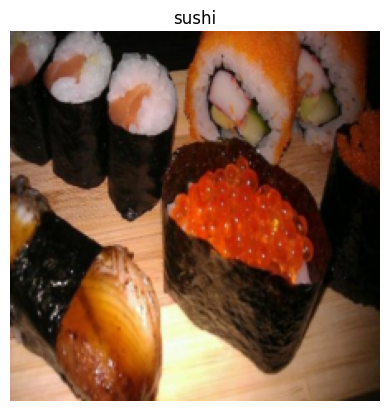

In [25]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [26]:
# Get flattened image patch embeddings in right shape
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1) # [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")

Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

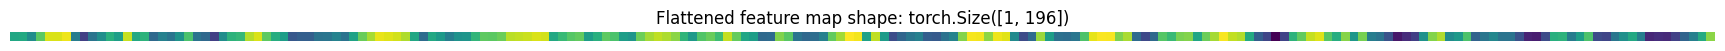

In [27]:
single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]

plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis("off")

In [28]:
# See the flattened feature map as a tensor
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[-0.4278, -0.4192, -0.5357, -0.2794, -0.0830, -0.0814, -0.0533, -0.6024,
          -0.8385, -0.6450, -0.5340, -0.3924, -0.4675, -0.1108, -0.4240, -0.3813,
          -0.6846, -0.5875, -0.6385, -0.5150, -0.3104, -0.6459, -0.6922, -0.8397,
          -0.5359, -0.3792, -0.3603, -0.1385, -0.0844, -0.2757, -0.4049, -0.4699,
          -0.7528, -0.7255, -0.7250, -0.6453, -0.6403, -0.5853, -0.6483, -0.4514,
          -0.2539, -0.1566, -0.0615, -0.0747, -0.0964, -0.1452, -0.4287, -0.6750,
          -0.4248, -0.4821, -0.5968, -0.5171, -0.5079, -0.3700, -0.2762, -0.2775,
          -0.2499, -0.1287, -0.1178, -0.1076, -0.0845, -0.0960, -0.4230, -0.3543,
          -0.2892, -0.2657, -0.4694, -0.3965, -0.2744, -0.3111, -0.4714, -0.5032,
          -0.2465, -0.1626, -0.1219, -0.1495, -0.1992, -0.3728, -0.4869, -0.2994,
          -0.2576, -0.3391, -0.1128, -0.2640, -0.4340, -0.4702, -0.6860, -0.6798,
          -0.2160, -0.2850, -0.6415, -0.6901, -0.6702, -0.5888, -0.2668, -0.1673,
          -0.026

### 4.5 Putting it all together

In [29]:
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """

    def __init__(self,
                 in_channels=3,
                 patch_size=16,
                 embedding_dim=768):
        super().__init__()
        
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)
        
        self.flatten = nn.Flatten(start_dim=2,
                                  end_dim=3)
        
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Image size must be divisible by patch size | Image shape: {image_resolution} | Patch size: {patch_size}"

        x_patched = self.patcher(x)
        x_flatten = self.flatten(x_patched)
        return x_flatten.permute(0,2,1)

In [30]:
set_seeds()

patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

print(f"Original shape of image: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Image shape after going through patchify: {patch_embedded_image.shape}")

Original shape of image: torch.Size([1, 3, 224, 224])
Image shape after going through patchify: torch.Size([1, 196, 768])


In [31]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
summary(PatchEmbedding(),
        input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

### 4.6 Creating the class token embedding

In [32]:
print(patch_embedded_image)
print(f"patch embedded image shape: {patch_embedded_image.shape}")

tensor([[[-0.5158,  0.1071, -0.0194,  ...,  0.2911, -0.1940,  0.1216],
         [-0.5381, -0.0953, -0.1421,  ...,  0.3663, -0.0388,  0.4155],
         [-0.7732,  0.2113, -0.1510,  ...,  0.4535, -0.1313,  0.2426],
         ...,
         [-0.5114,  0.0627, -0.1034,  ...,  0.3370, -0.2636,  0.2223],
         [-0.3092,  0.0200, -0.0525,  ...,  0.2131, -0.1936,  0.1861],
         [-0.1684,  0.0010, -0.0338,  ...,  0.0398, -0.0885,  0.1034]]],
       grad_fn=<PermuteBackward0>)
patch embedded image shape: torch.Size([1, 196, 768])


In [33]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [34]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.5158,  0.1071, -0.0194,  ...,  0.2911, -0.1940,  0.1216],
         [-0.5381, -0.0953, -0.1421,  ...,  0.3663, -0.0388,  0.4155],
         ...,
         [-0.5114,  0.0627, -0.1034,  ...,  0.3370, -0.2636,  0.2223],
         [-0.3092,  0.0200, -0.0525,  ...,  0.2131, -0.1936,  0.1861],
         [-0.1684,  0.0010, -0.0338,  ...,  0.0398, -0.0885,  0.1034]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 4.7 Creating the position embedding

(Date - 5/June/2026)

In [35]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [36]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.4842, 1.1071, 0.9806,  ..., 1.2911, 0.8060, 1.1216],
         [0.4619, 0.9047, 0.8579,  ..., 1.3663, 0.9612, 1.4155],
         ...,
         [0.4886, 1.0627, 0.8966,  ..., 1.3370, 0.7364, 1.2223],
         [0.6908, 1.0200, 0.9475,  ..., 1.2131, 0.8064, 1.1861],
         [0.8316, 1.0010, 0.9662,  ..., 1.0398, 0.9115, 1.1034]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 4.8 putting it all together

In [37]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


## 5. Equation 2: Multi-Head Attention (MSA)

(Date - 8/July/2026)

In [38]:
class MSA(nn.Module):
    def __init__(self,
                 embedding_dimension:int=768,
                 num_heads:int=12,
                 attn_dropout:float=0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dimension)

        self.MSA = nn.MultiheadAttention(embed_dim=embedding_dimension,
                                         num_heads=num_heads,
                                         batch_first=True,
                                         dropout=attn_dropout)
        
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.MSA(query=x,
                     key=x,
                     value=x,
                     need_weights=False)
        
        return attn_output

In [39]:
MSA_block = MSA(embedding_dimension=768,
                num_heads=12)

Image_through_MSA_block = MSA_block(patch_and_position_embedding)
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")
print(f"Shape after Image goes through the MSA block: {Image_through_MSA_block.shape}")

Patch and position embedding shape: torch.Size([1, 197, 768])
Shape after Image goes through the MSA block: torch.Size([1, 197, 768])


## 6. Equation 3: Multilayer Perceptron (MLP)

In [40]:
class MLP(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 MLP_size:int=3072,
                 dropout:float=0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.MLP = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=MLP_size),

            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=MLP_size,
                      out_features=embedding_dim),
            nn.Dropout(p=dropout)
        )
    
    def forward(self, x):
        x = self.layer_norm(x)
        MLP_output = self.MLP(x)
        return MLP_output

In [41]:
MLP_block = MLP(embedding_dim=768,
                MLP_size=3072,
                dropout=0.1)

patched_image_through_MLP = MLP_block(patch_and_position_embedding)
print(f"Shape of Input: {patch_and_position_embedding.shape}")
print(f"Shape after going through the MLP block: {patched_image_through_MLP.shape}")

Shape of Input: torch.Size([1, 197, 768])
Shape after going through the MLP block: torch.Size([1, 197, 768])


## 7. Creating the Transformer encoder block

### 7.1 Manual creation

In [42]:
class TransformerEncoderBlock(nn.Module):
    """
    Creates a Transformer Encoder Block.
    """
    def __init__(self,
                 embedding_dimension:int=768,
                 mlp_size:int=3072,
                 mlp_dropout:float=0.1,
                 attn_dropout:float=0,
                 num_heads:int=12):
        super().__init__()

        self.MSA_block = MSA(embedding_dimension=embedding_dimension,
                             num_heads=num_heads,
                             attn_dropout=attn_dropout)
        
        self.MLP_block = MLP(embedding_dim=embedding_dimension,
                             dropout=mlp_dropout,
                             MLP_size=mlp_size)
        
    def forward(self, x):
        x = self.MSA_block(x) + x
        x = self.MLP_block(x) + x
        return x

In [43]:
# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoderBlock()

# Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MSA (MSA_block)                                  [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (MSA)                    --                   [1, 197, 768]        2,362,368            True
├─MLP (MLP_block)                                  [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (MLP)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

### 7.2 Auto-creation

In [44]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [45]:
# Get the output of PyTorch's version of the Transformer Encoder (uncomment for full output)
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

## 8. Putting it all together
(Date - 12/July/2026)

In [46]:
class ViT(nn.Module):
    def __init__(self,
                 img_size:int=224, # Training resolution from Table 3 in ViT paper
                 in_channels:int=3, # Number of channels in input image
                 patch_size:int=16, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=1000):
        super().__init__()

        assert img_size % patch_size == 0, f"Image size is not divisible by patch size. | Image size: {img_size} | Patch size: {patch_size}"

        self.num_patches = int((img_size**2)/(patch_size**2))

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                            requires_grad=True)
        
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)
        
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dimension=embedding_dim,
                                                                           mlp_size=mlp_size,
                                                                           num_heads=num_heads,
                                                                           mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
                                        )
        
    def forward(self, x):
        
        batch_size = x.shape[0]
        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.classifier(x[:, 0]) # You may also write x[:, 0, :]... the last semicolon is omitted because PyTorch allows us to do so. x[:, 0] selects the CLS token.

        return x

Wuhuuu! We built the ViT!

In [47]:
# Example of creating the class embedding and expanding over a batch dimension
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [48]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))


# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[0.2525, 0.8748, 1.2374]], grad_fn=<AddmmBackward0>)

### 8.1 Getting a visual summary of our ViT model

In [49]:
# Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                     [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)            [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                       [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                      [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                 [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)            [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)            [32, 197, 768]       [32, 197, 768]       --                   True
│    │    └─MSA (MSA_block)                   [32, 197, 768]       [32, 197, 768]      

Exercise: Try changing the number of classes above from 3 to 1000. You will see an increase in the number of total parameters (i.e. 85,000,963 -> 86,567,656)

## 9. Training our model

In [50]:
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=0.003,
                             betas=(0.9, 0.999), # Set by default
                             weight_decay=0.3
                             ) 

loss_fn = nn.CrossEntropyLoss()

set_seeds()

results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       epochs=1,
                       device=device,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       writer=create_writer(experiment_name="ViT_exp_1",
                                            model_name="ViT_base"))

[INFO] Created SummaryWriter, saving to: runs\2026-07-23\ViT_exp_1\ViT_base...


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 5.3084 | train_acc: 0.3594 | test_loss: 5.1902 | test_acc: 0.2604


100%|██████████| 1/1 [14:07<00:00, 847.58s/it]


(Date - 13/July/2026)

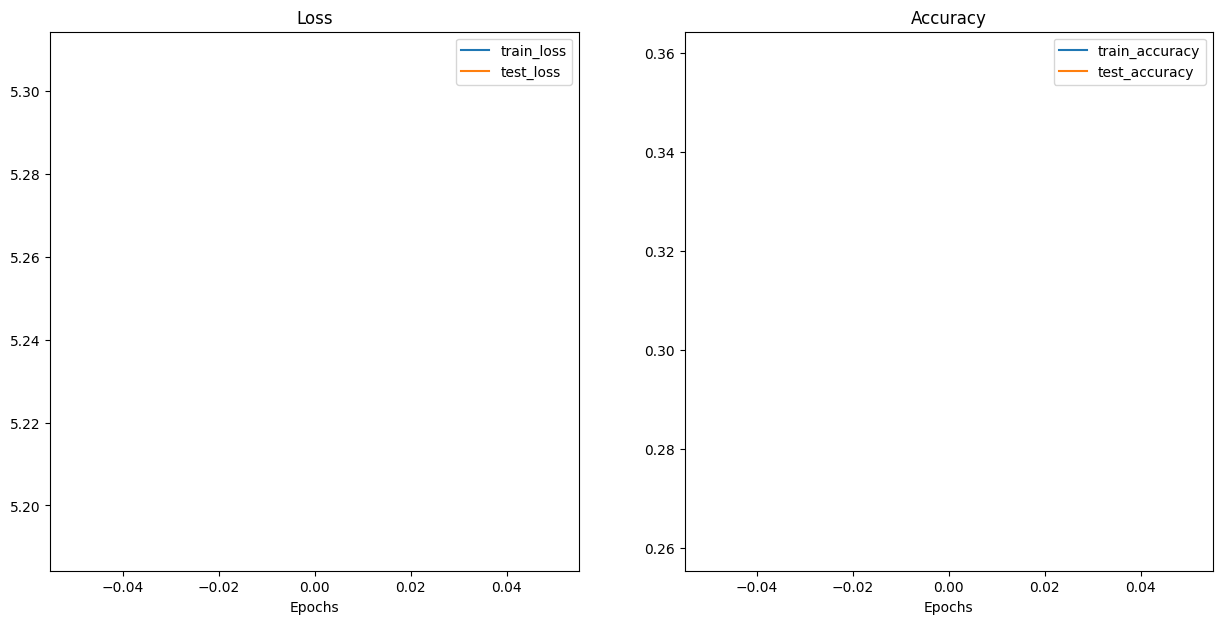

In [51]:
plot_loss_curves(results)

## 10. Using a pretrained model

(Date - 14/July/2026)

In [52]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # requires torchvision >= 0.13, "DEFAULT" means best available

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Change the classifier head (set the seeds to ensure same initialization with linear head)
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)
# pretrained_vit # uncomment for model output

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\user/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:13<00:00, 25.2MB/s] 


In [53]:
# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 3]              768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

In [54]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [55]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     train_transform=pretrained_vit_transforms,
                                                                                                     test_transform=pretrained_vit_transforms,
                                                                                                     batch_size=32)


In [56]:
# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=test_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device,
                                      writer=create_writer(experiment_name="ViT_exp_2",
                                            model_name="ViT_base"))

[INFO] Created SummaryWriter, saving to: runs\2026-07-23\ViT_exp_2\ViT_base...


 10%|█         | 1/10 [01:55<17:17, 115.29s/it]

Epoch: 1 | train_loss: 0.7663 | train_acc: 0.7188 | test_loss: 0.5435 | test_acc: 0.8769


 20%|██        | 2/10 [03:38<14:27, 108.40s/it]

Epoch: 2 | train_loss: 0.3436 | train_acc: 0.9453 | test_loss: 0.3257 | test_acc: 0.8977


...

Epoch: 8 | train_loss: 0.0793 | train_acc: 0.9844 | test_loss: 0.2268 | test_acc: 0.9081


 90%|█████████ | 9/10 [16:13<01:48, 108.46s/it]

Epoch: 9 | train_loss: 0.1084 | train_acc: 0.9883 | test_loss: 0.2064 | test_acc: 0.9384


100%|██████████| 10/10 [18:07<00:00, 108.75s/it]

Epoch: 10 | train_loss: 0.0646 | train_acc: 0.9922 | test_loss: 0.1795 | test_acc: 0.9176


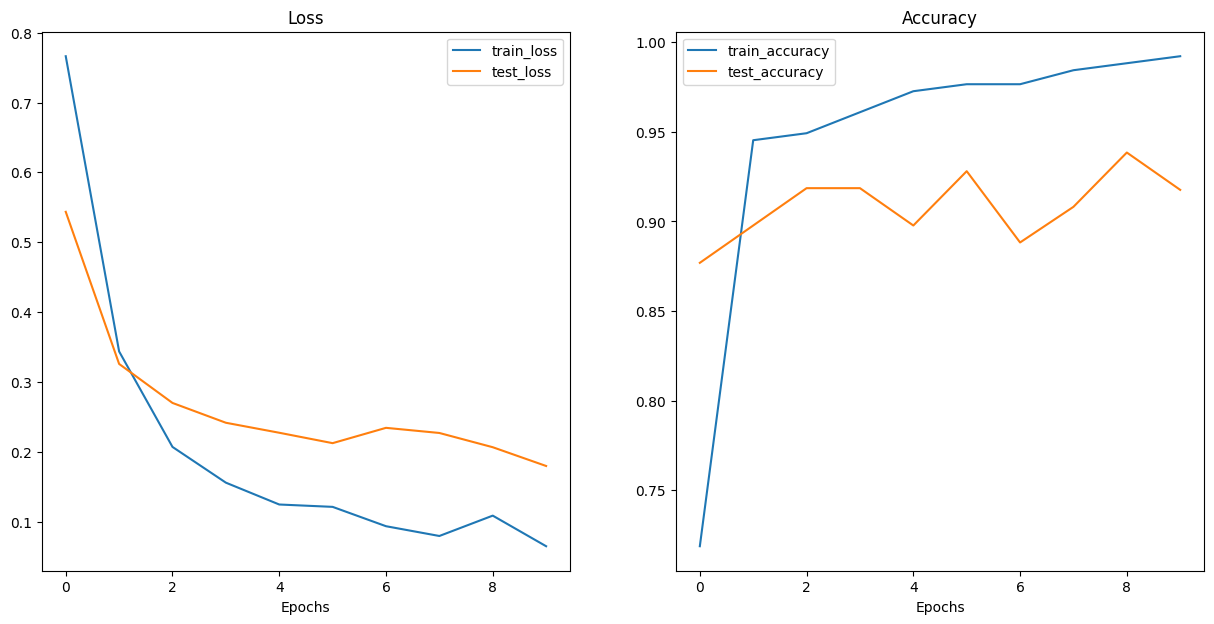

In [57]:
plot_loss_curves(pretrained_vit_results)

In [58]:
utils.save_model(model=pretrained_vit,
                 target_dir="../models",
                 model_name="08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth")

[INFO] Saving model to: ..\models\08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth


In [61]:
pretrained_vit_model_size = Path("../models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


## 11. Making prediction on a custom image

Prediction : pizza
Probability : 0.9364635348320007


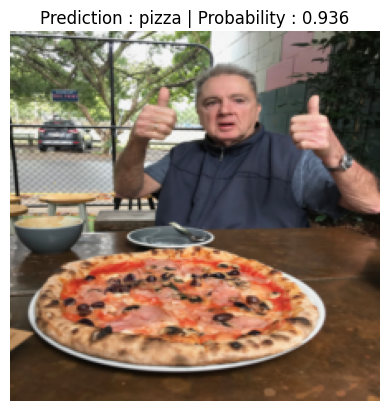

In [73]:
# # Setup custom image path
custom_image_path = "DanielDad.jpeg"

# # Download the image if it doesn't already exist
# if not custom_image_path.is_file():
#     with open(custom_image_path, "wb") as f:
#         # When downloading from GitHub, need to use the "raw" file link
#         request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
#         print(f"Downloading {custom_image_path}...")
#         f.write(request.content)
# else:
#     print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
predict.pred_and_plot_image(model=pretrained_vit,
                    image_path=str(custom_image_path),
                    class_names=class_names)